In [1]:
import time, os, sys, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras import layers, metrics, losses, callbacks, regularizers
from sklearn.model_selection import train_test_split

SEED = 54
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print("Python version: {}".format(sys.version_info))
print("Numpy version: {}".format(np.version.version))
print("Tensorflow version: {}".format(tf.__version__))

2026-06-02 03:10:14.170043: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780369814.394053      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780369814.459292      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780369814.997350      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780369814.997412      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780369814.997415      23 computation_placer.cc:177] computation placer alr

Python version: sys.version_info(major=3, minor=12, micro=13, releaselevel='final', serial=0)
Numpy version: 2.4.6
Tensorflow version: 2.19.0


In [2]:
!unzip -q -n /kaggle/input/competitions/galaxy-zoo-the-galaxy-challenge/images_training_rev1.zip -d ../temp/
!unzip -q -n /kaggle/input/competitions/galaxy-zoo-the-galaxy-challenge/images_test_rev1.zip -d ../temp/
labels_pd = pd.read_csv('/kaggle/input/competitions/galaxy-zoo-the-galaxy-challenge/training_solutions_rev1.zip', compression='zip')
print("Labels shape: {}".format(labels_pd.shape))
print("Columns: {}".format(list(labels_pd.columns)))
labels_pd.head()

Labels shape: (61578, 38)
Columns: ['GalaxyID', 'Class1.1', 'Class1.2', 'Class1.3', 'Class2.1', 'Class2.2', 'Class3.1', 'Class3.2', 'Class4.1', 'Class4.2', 'Class5.1', 'Class5.2', 'Class5.3', 'Class5.4', 'Class6.1', 'Class6.2', 'Class7.1', 'Class7.2', 'Class7.3', 'Class8.1', 'Class8.2', 'Class8.3', 'Class8.4', 'Class8.5', 'Class8.6', 'Class8.7', 'Class9.1', 'Class9.2', 'Class9.3', 'Class10.1', 'Class10.2', 'Class10.3', 'Class11.1', 'Class11.2', 'Class11.3', 'Class11.4', 'Class11.5', 'Class11.6']


,GalaxyID,Class1.1,Class1.2,Class1.3,Class2.1,Class2.2,Class3.1,Class3.2,Class4.1,Class4.2,...,Class9.3,Class10.1,Class10.2,Class10.3,Class11.1,Class11.2,Class11.3,Class11.4,Class11.5,Class11.6
0,100008,0.383147,0.616853,0.000000,0.000000,0.616853,0.038452,0.578401,0.418398,0.198455,...,0.000000,0.279952,0.138445,0.000000,0.000000,0.092886,0.0,0.0,0.0,0.325512
1,100023,0.327001,0.663777,0.009222,0.031178,0.632599,0.467370,0.165229,0.591328,0.041271,...,0.018764,0.000000,0.131378,0.459950,0.000000,0.591328,0.0,0.0,0.0,0.000000
2,100053,0.765717,0.177352,0.056931,0.000000,0.177352,0.000000,0.177352,0.000000,0.177352,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000
3,100078,0.693377,0.238564,0.068059,0.000000,0.238564,0.109493,0.129071,0.189098,0.049466,...,0.000000,0.094549,0.000000,0.094549,0.189098,0.000000,0.0,0.0,0.0,0.000000
4,100090,0.933839,0.000000,0.066161,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000


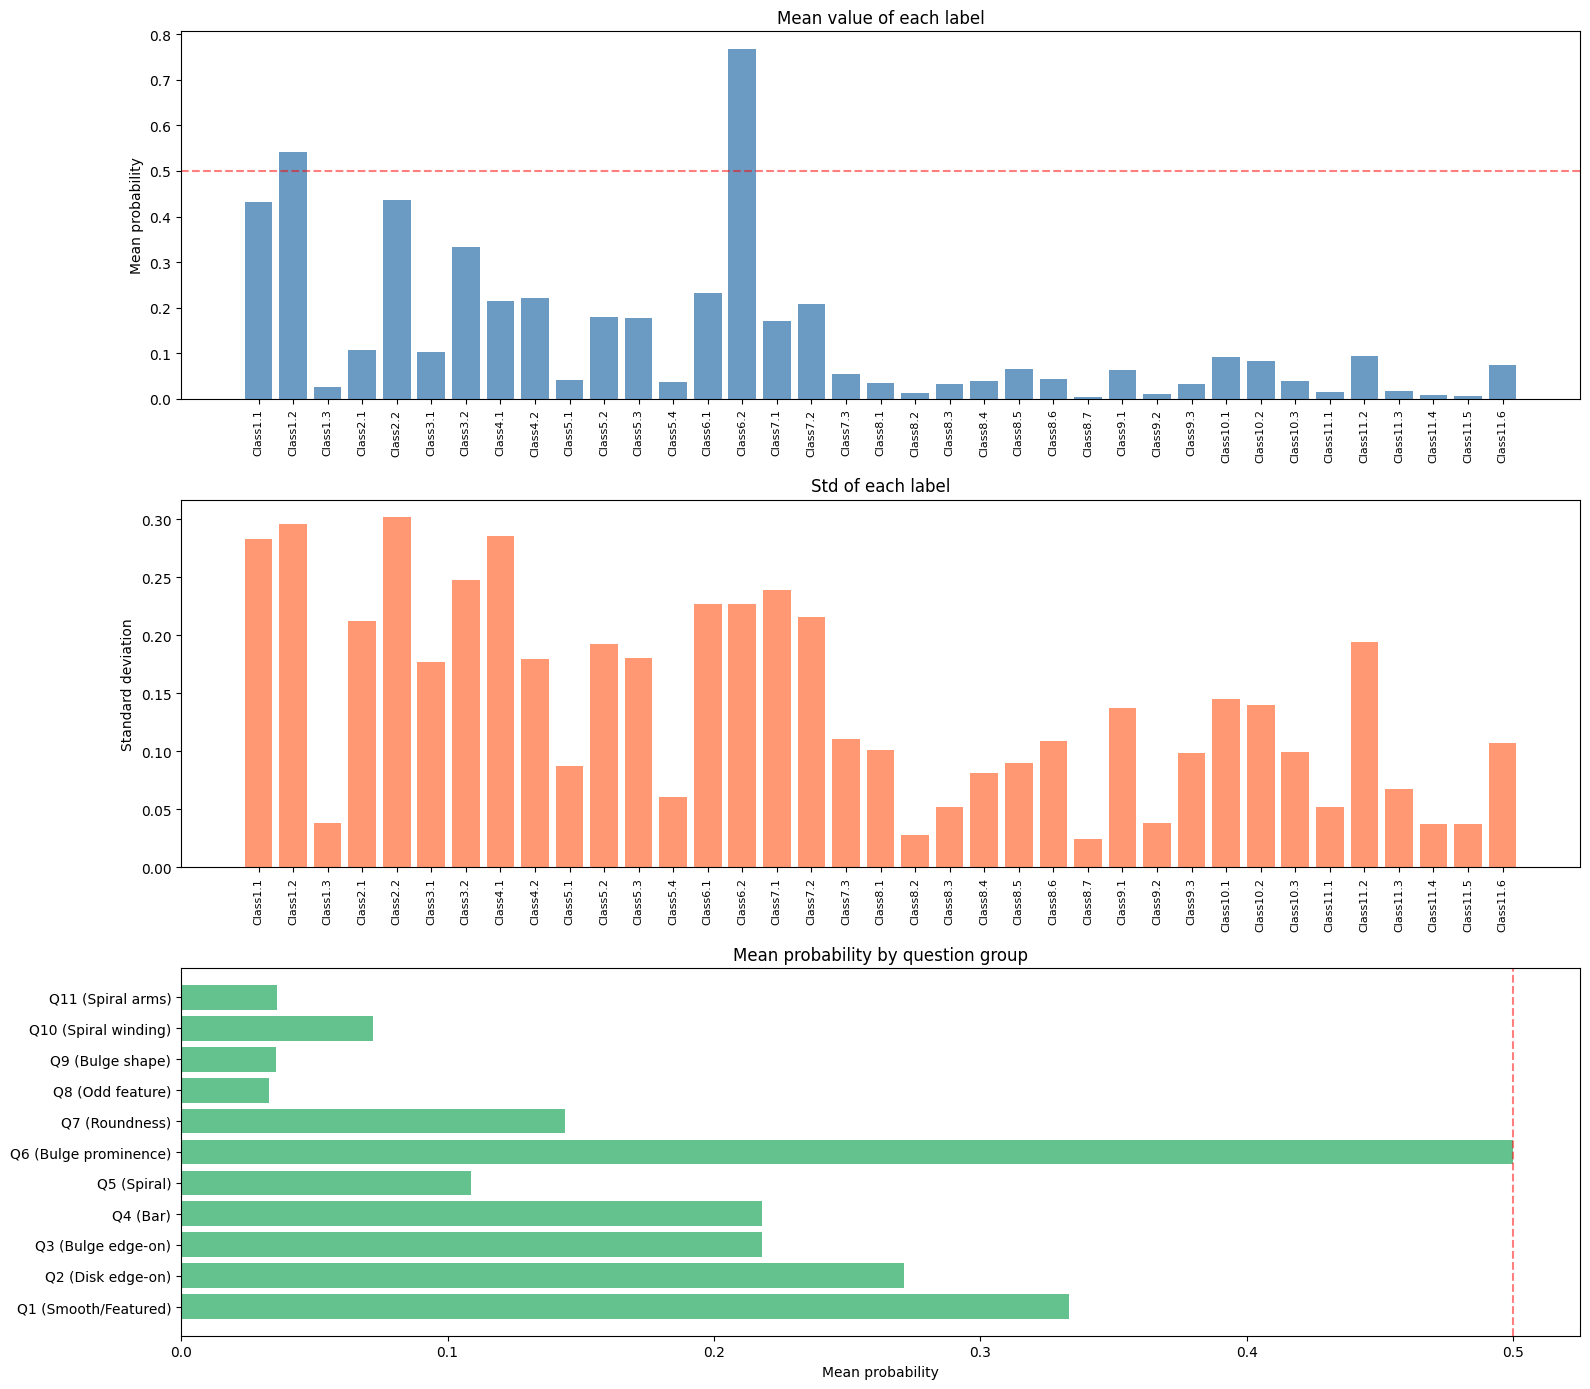

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

label_cols = labels_pd.columns[1:]
means = labels_pd[label_cols].mean()
stds = labels_pd[label_cols].std()

axes[0].bar(range(len(label_cols)), means, color='steelblue', alpha=0.8)
axes[0].set_xticks(range(len(label_cols)))
axes[0].set_xticklabels(label_cols, rotation=90, fontsize=8)
axes[0].set_title('Mean value of each label')
axes[0].set_ylabel('Mean probability')
axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5)

axes[1].bar(range(len(label_cols)), stds, color='coral', alpha=0.8)
axes[1].set_xticks(range(len(label_cols)))
axes[1].set_xticklabels(label_cols, rotation=90, fontsize=8)
axes[1].set_title('Std of each label')
axes[1].set_ylabel('Standard deviation')

question_groups = {
    'Q1 (Smooth/Featured)':    ['Class1.1','Class1.2','Class1.3'],
    'Q2 (Disk edge-on)':       ['Class2.1','Class2.2'],
    'Q3 (Bulge edge-on)':      ['Class3.1','Class3.2'],
    'Q4 (Bar)':                ['Class4.1','Class4.2'],
    'Q5 (Spiral)':             ['Class5.1','Class5.2','Class5.3','Class5.4'],
    'Q6 (Bulge prominence)':   ['Class6.1','Class6.2'],
    'Q7 (Roundness)':          ['Class7.1','Class7.2','Class7.3'],
    'Q8 (Odd feature)':        ['Class8.1','Class8.2','Class8.3','Class8.4','Class8.5','Class8.6','Class8.7'],
    'Q9 (Bulge shape)':        ['Class9.1','Class9.2','Class9.3'],
    'Q10 (Spiral winding)':    ['Class10.1','Class10.2','Class10.3'],
    'Q11 (Spiral arms)':       ['Class11.1','Class11.2','Class11.3','Class11.4','Class11.5','Class11.6'],
}
group_means = {k: labels_pd[v].values.mean() for k, v in question_groups.items()}
axes[2].barh(list(group_means.keys()), list(group_means.values()), color='mediumseagreen', alpha=0.8)
axes[2].set_title('Mean probability by question group')
axes[2].set_xlabel('Mean probability')
axes[2].axvline(x=0.5, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

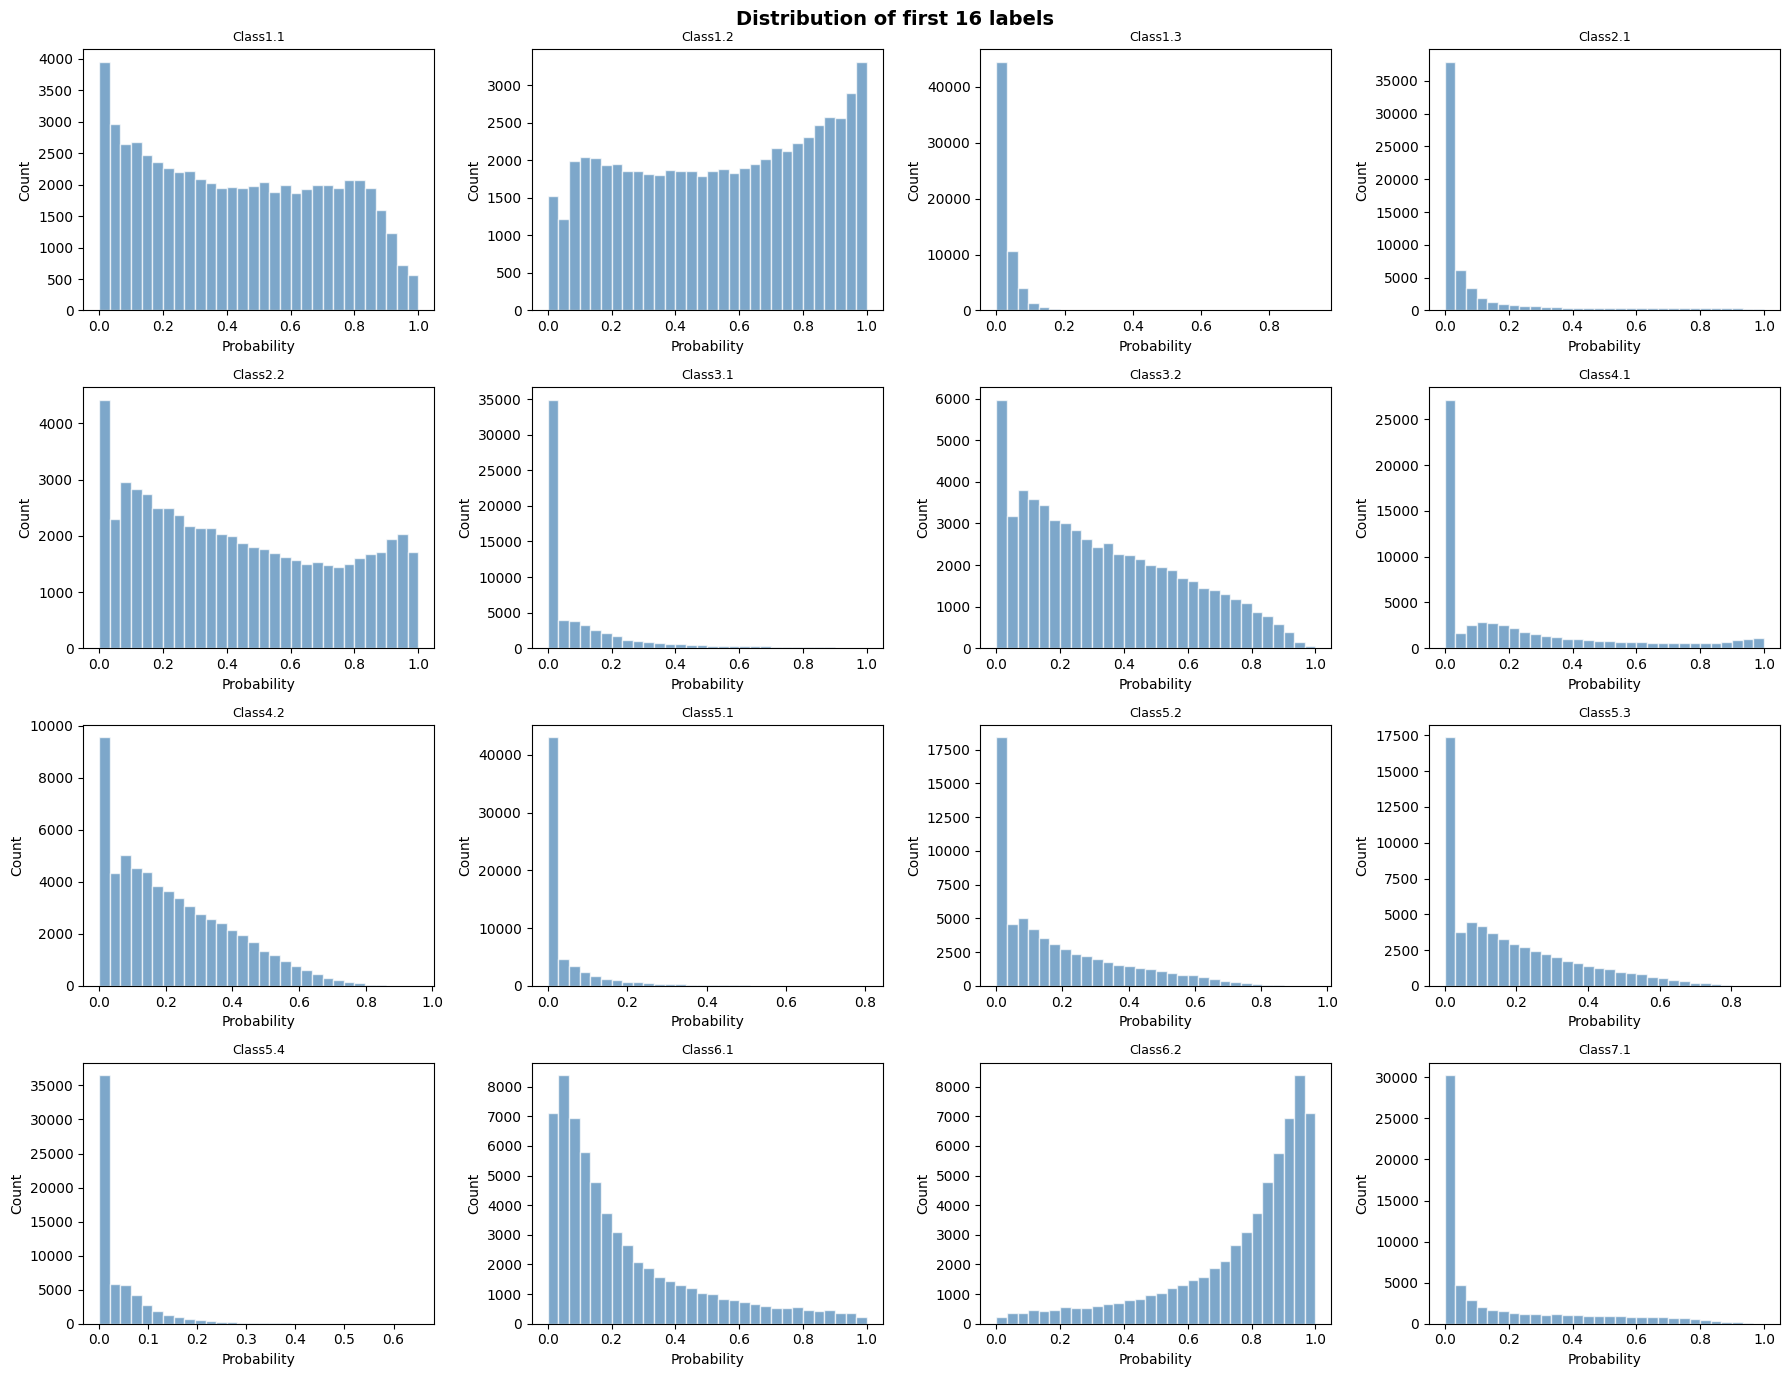

In [4]:
label_cols = labels_pd.columns[1:]
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()
selected = label_cols[:16]
for i, col in enumerate(selected):
    axes[i].hist(labels_pd[col], bins=30, color='steelblue', alpha=0.7, edgecolor='white')
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('Probability')
    axes[i].set_ylabel('Count')
plt.suptitle('Distribution of first 16 labels', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [5]:
strategy = tf.distribute.get_strategy()
print('Running on CPU/GPU')
print('Number of replicas: {}'.format(strategy.num_replicas_in_sync))

Running on CPU/GPU
Number of replicas: 1


In [6]:
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE
IMAGE_SIZE = 160

def get_image_and_features(image_path, training=True):
    # Đọc bằng Python thuần, tránh TF ops trong py_function
    path_str = image_path.numpy().decode('utf-8')
    
    raw = tf.io.read_file(path_str)
    image = tf.image.decode_jpeg(raw, channels=3)
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.resize(image, [IMAGE_SIZE, IMAGE_SIZE])  # thay crop_or_pad
    
    if training:
        filename = os.path.basename(path_str)
        galaxyID = int(filename.replace('.jpg', ''))
        galaxy_row = labels_pd.loc[labels_pd['GalaxyID'] == galaxyID]
        features = tf.cast(galaxy_row.iloc[0, 1:].values, tf.float32)
        return image, features
    else:
        return image

def dataset_preprocessing(images_path, training=True):
    images_path_ds = tf.data.Dataset.from_tensor_slices(images_path)
    if training:
        dataset = images_path_ds.map(
            lambda x: tf.py_function(func=get_image_and_features, inp=[x], Tout=(tf.float32, tf.float32)),
            num_parallel_calls=AUTOTUNE)
        dataset = dataset.map(lambda img, lbl: (
            tf.ensure_shape(img, [IMAGE_SIZE, IMAGE_SIZE, 3]),
            tf.ensure_shape(lbl, [37])
        ))
    else:
        dataset = images_path_ds.map(
            lambda x: tf.py_function(func=get_image_and_features, inp=[x, False], Tout=tf.float32),
            num_parallel_calls=AUTOTUNE)
        dataset = dataset.map(lambda img: tf.ensure_shape(img, [IMAGE_SIZE, IMAGE_SIZE, 3]))
    dataset = dataset.shuffle(2048) if training else dataset
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)
    return dataset

images_path = tf.io.gfile.glob('../temp/images_training_rev1/*')
tf.random.set_seed(SEED)
images_path = tf.random.shuffle(images_path)
samples_size = len(images_path)
print("Total samples: {}".format(samples_size))

splitIndex = int(np.floor(samples_size * 0.8))
images_path_train = images_path[:splitIndex]
images_path_val = images_path[splitIndex:]

train_dataset = dataset_preprocessing(images_path_train)
val_dataset = dataset_preprocessing(images_path_val)

print('Training batches: %d' % tf.data.experimental.cardinality(train_dataset))
print('Validation batches: %d' % tf.data.experimental.cardinality(val_dataset))

I0000 00:00:1780369872.290340      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780369872.296356      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Total samples: 61578
Training batches: 770
Validation batches: 193


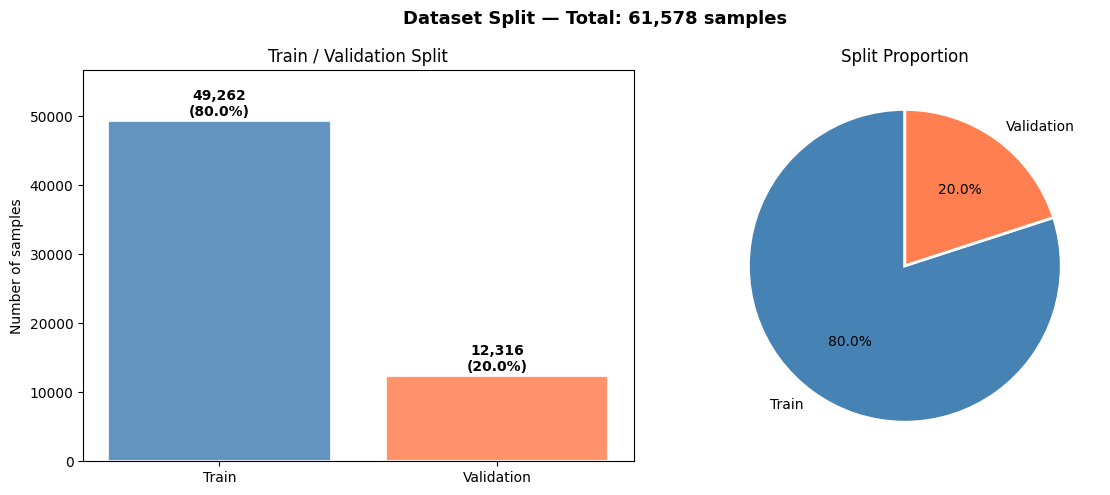

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

split_labels = ['Train', 'Validation']
split_counts = [len(images_path_train), len(images_path_val)]
colors = ['steelblue', 'coral']

bars = axes[0].bar(split_labels, split_counts, color=colors, alpha=0.85, edgecolor='white', linewidth=1.5)
for bar, count in zip(bars, split_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                 f'{count:,}\n({count/samples_size*100:.1f}%)',
                 ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Train / Validation Split')
axes[0].set_ylabel('Number of samples')
axes[0].set_ylim(0, max(split_counts) * 1.15)

axes[1].pie(split_counts, labels=split_labels, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Split Proportion')

plt.suptitle(f'Dataset Split — Total: {samples_size:,} samples', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

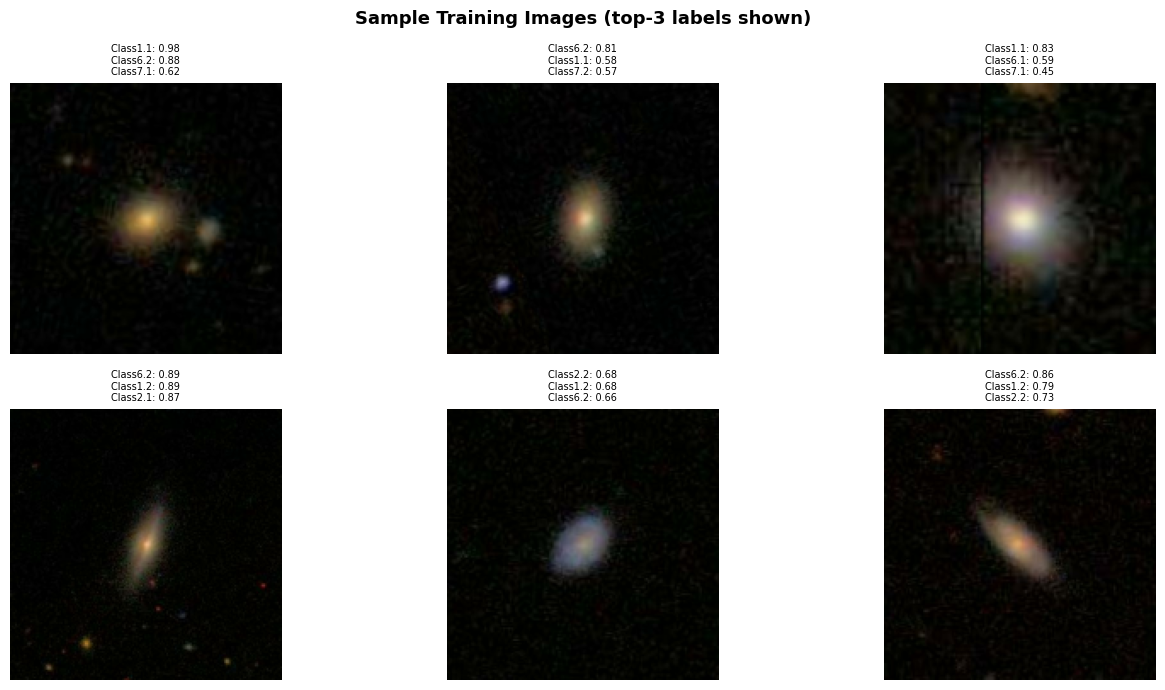

Image shape: (160, 160, 3)


In [8]:
def plot_sample_images(dataset, rows=2, cols=3):
    fig, axes = plt.subplots(rows, cols, figsize=(14, 7))
    batch = list(dataset.take(1).as_numpy_iterator())[0]
    images, labels = batch[0], batch[1]
    for i in range(rows):
        for j in range(cols):
            idx = cols * i + j
            axes[i, j].imshow(images[idx])
            axes[i, j].axis('off')
            top3_idx = np.argsort(labels[idx])[::-1][:3]
            label_cols = labels_pd.columns[1:]
            title = '\n'.join([f'{label_cols[k]}: {labels[idx][k]:.2f}' for k in top3_idx])
            axes[i, j].set_title(title, fontsize=7)
    plt.suptitle('Sample Training Images (top-3 labels shown)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    return images[0].shape

image_shape = plot_sample_images(train_dataset)
print("Image shape: {}".format(image_shape))

In [9]:
def create_model(input_shape, use_augmentation=True):
    base = tf.keras.models.Sequential(name='cnn_backbone', layers=[
        layers.Conv2D(16, (6, 6), activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.1),

        layers.Conv2D(32, (5, 5), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.1),

        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.1),

        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.1),

        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(37, activation='sigmoid'),
    ])

    if use_augmentation:
        augmentation = tf.keras.models.Sequential(name='augmentation', layers=[
            layers.RandomFlip('horizontal_and_vertical', input_shape=input_shape),
            layers.RandomRotation(0.3),
            layers.RandomZoom(height_factor=0.2, width_factor=0.2),
            layers.RandomContrast(0.05),
        ])
        model = tf.keras.models.Sequential(name='galaxyClassifier', layers=[augmentation, base])
    else:
        model = base
        model._name = 'galaxyClassifier'

    return model

with strategy.scope():
    input_shape = (IMAGE_SIZE, IMAGE_SIZE, 3)
    model = create_model(input_shape, use_augmentation=True)
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
    loss_func = losses.MeanSquaredError()
    model.compile(
        loss=loss_func,
        optimizer=optimizer,
        metrics=[
            tf.keras.metrics.RootMeanSquaredError(name='rmse'),
            tf.keras.metrics.MeanAbsoluteError(name='mae'),
        ]
    )

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "galaxyClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_backbone (Sequential)       │ (None, 37)             │     3,460,501 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,460,501 (13.20 MB)

 Trainable params: 3,460,021 (13.20 MB)

 Non-trainable params: 480 (1.88 KB)

In [10]:
NUM_EPOCHS = 50

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.2, patience=7, min_lr=1e-5, verbose=1)

early_stop = callbacks.EarlyStopping(
    monitor='val_loss', mode='min', verbose=1, patience=10, restore_best_weights=True)

checkpoint = callbacks.ModelCheckpoint(
    'best_model.keras', save_best_only=True, monitor='val_rmse', mode='min', verbose=1)

class LRLogger(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        lr = float(tf.keras.backend.get_value(self.model.optimizer.learning_rate))
        logs['lr'] = lr

lr_logger = LRLogger()

callbacks_list = [reduce_lr, early_stop, checkpoint, lr_logger]

print('------- Training -------')
start = time.time()
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=NUM_EPOCHS,
    callbacks=callbacks_list,
    verbose=1
)
end = time.time()
print("Total training time: {:.2f} hours".format((end - start) / 3600))

------- Training -------
Epoch 1/50


E0000 00:00:1780369887.907783      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/galaxyClassifier_1/cnn_backbone_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1780369897.312750      78 cuda_dnn.cc:529] Loaded cuDNN version 91002


770/770 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - loss: 0.0379 - mae: 0.1056 - rmse: 0.1914
Epoch 1: val_rmse improved from None to 0.13356, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
770/770 ━━━━━━━━━━━━━━━━━━━━ 278s 340ms/step - loss: 0.0260 - mae: 0.0915 - rmse: 0.1612 - val_loss: 0.0178 - val_mae: 0.0779 - val_rmse: 0.1336 - learning_rate: 0.0010 - lr: 0.0010
Epoch 2/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - loss: 0.0174 - mae: 0.0768 - rmse: 0.1318
Epoch 2: val_rmse improved from 0.13356 to 0.12097, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
770/770 ━━━━━━━━━━━━━━━━━━━━ 267s 337ms/step - loss: 0.0166 - mae: 0.0748 - rmse: 0.1289 - val_loss: 0.0146 - val_mae: 0.0705 - val_rmse: 0.1210 - learning_rate: 0.0010 - lr: 0.0010
Epoch 3/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - loss: 0.0147 - mae: 0.0699 - rmse: 0.1213
Epoch 3: val_rmse improved from 0.12097 to 0.11381, saving model to best_model.ker

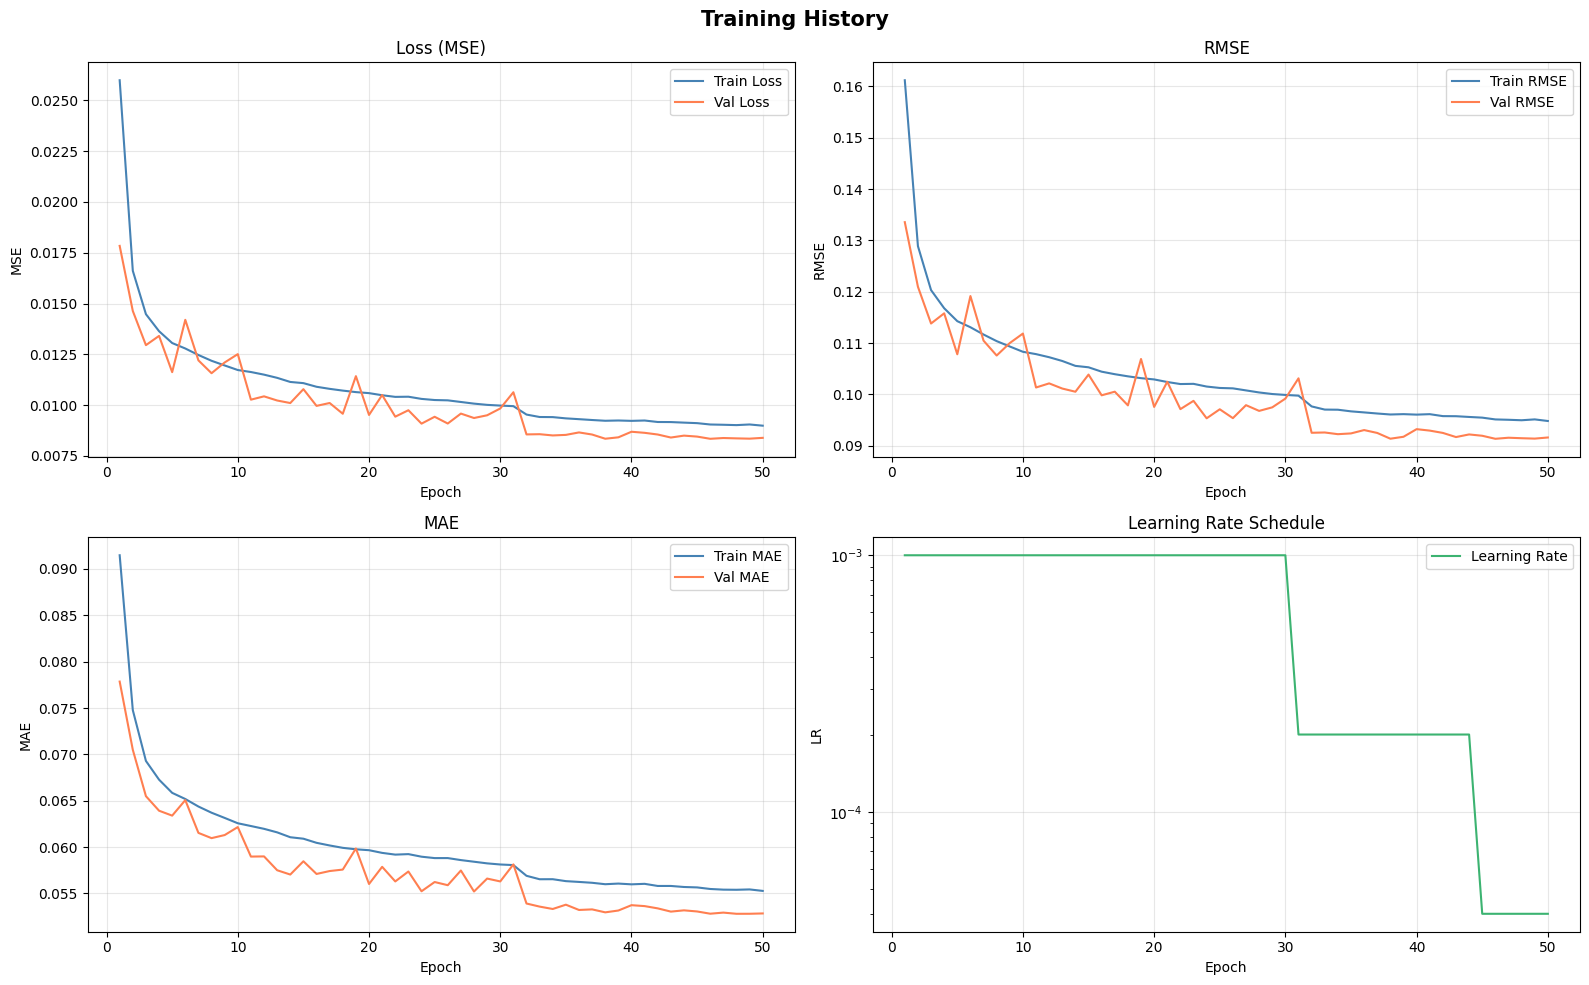

In [11]:
hist = history.history
epochs_range = range(1, len(hist['loss']) + 1)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(epochs_range, hist['loss'], label='Train Loss', color='steelblue')
axes[0, 0].plot(epochs_range, hist['val_loss'], label='Val Loss', color='coral')
axes[0, 0].set_title('Loss (MSE)')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('MSE')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(epochs_range, hist['rmse'], label='Train RMSE', color='steelblue')
axes[0, 1].plot(epochs_range, hist['val_rmse'], label='Val RMSE', color='coral')
axes[0, 1].set_title('RMSE')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('RMSE')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(epochs_range, hist['mae'], label='Train MAE', color='steelblue')
axes[1, 0].plot(epochs_range, hist['val_mae'], label='Val MAE', color='coral')
axes[1, 0].set_title('MAE')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('MAE')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(epochs_range, hist['lr'], label='Learning Rate', color='mediumseagreen')
axes[1, 1].set_title('Learning Rate Schedule')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('LR')
axes[1, 1].set_yscale('log')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.suptitle('Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
results = model.evaluate(val_dataset, verbose=1)
print("\nVal Loss (MSE): {:.5f}".format(results[0]))
print("Val RMSE:       {:.5f}".format(results[1]))
print("Val MAE:        {:.5f}".format(results[2]))

193/193 ━━━━━━━━━━━━━━━━━━━━ 46s 202ms/step - loss: 0.0083 - mae: 0.0528 - rmse: 0.0913

Val Loss (MSE): 0.00834
Val RMSE:       0.09134
Val MAE:        0.05282


In [13]:
y_true_list, y_pred_list = [], []
for images, labels in val_dataset:
    preds = model(images, training=False)
    y_true_list.append(labels.numpy())
    y_pred_list.append(preds.numpy())

y_true = np.vstack(y_true_list)
y_pred = np.vstack(y_pred_list)
print("y_true shape: {}".format(y_true.shape))
print("y_pred shape: {}".format(y_pred.shape))

y_true shape: (12316, 37)
y_pred shape: (12316, 37)


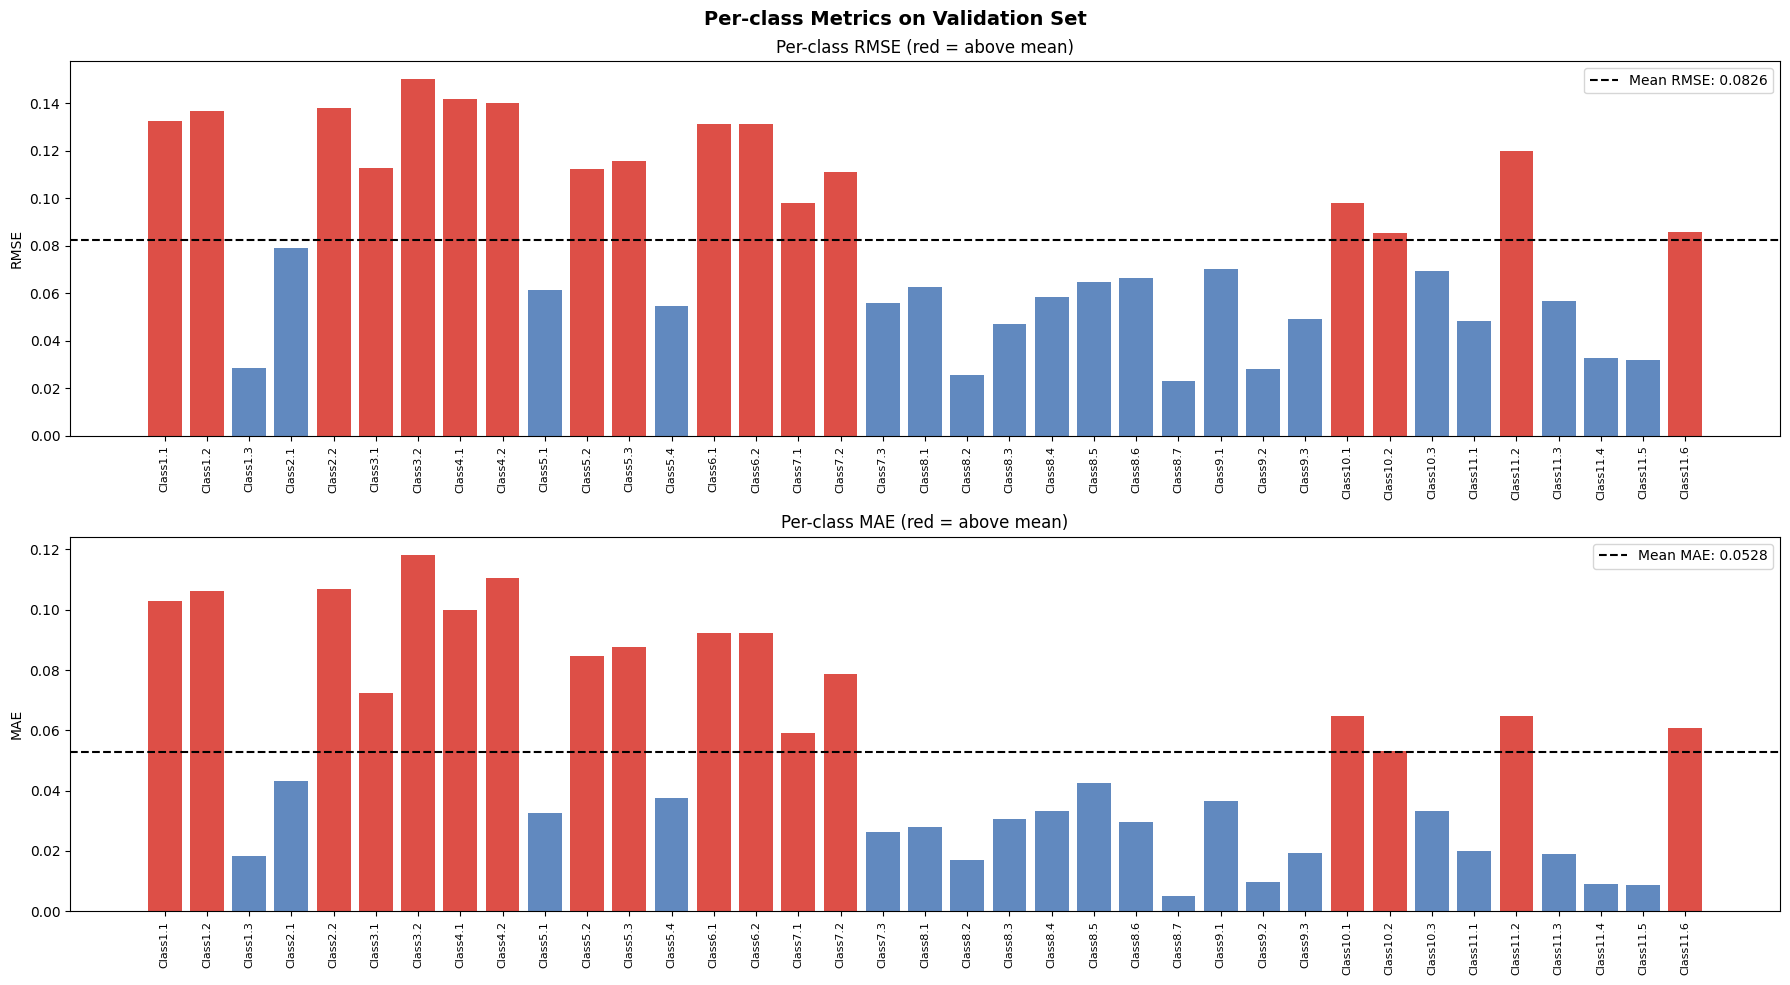


Top 5 worst RMSE classes:
  Class3.2: RMSE=0.1502, MAE=0.1183
  Class4.1: RMSE=0.1420, MAE=0.0998
  Class4.2: RMSE=0.1403, MAE=0.1104
  Class2.2: RMSE=0.1380, MAE=0.1068
  Class1.2: RMSE=0.1367, MAE=0.1062


In [14]:
label_cols = labels_pd.columns[1:].tolist()
per_class_rmse = np.sqrt(np.mean((y_pred - y_true) ** 2, axis=0))
per_class_mae = np.mean(np.abs(y_pred - y_true), axis=0)

fig, axes = plt.subplots(2, 1, figsize=(18, 10))

colors_rmse = ['#d73027' if v > np.mean(per_class_rmse) else '#4575b4' for v in per_class_rmse]
axes[0].bar(range(37), per_class_rmse, color=colors_rmse, alpha=0.85)
axes[0].axhline(np.mean(per_class_rmse), color='black', linestyle='--', label=f'Mean RMSE: {np.mean(per_class_rmse):.4f}')
axes[0].set_xticks(range(37))
axes[0].set_xticklabels(label_cols, rotation=90, fontsize=8)
axes[0].set_title('Per-class RMSE (red = above mean)')
axes[0].set_ylabel('RMSE')
axes[0].legend()

colors_mae = ['#d73027' if v > np.mean(per_class_mae) else '#4575b4' for v in per_class_mae]
axes[1].bar(range(37), per_class_mae, color=colors_mae, alpha=0.85)
axes[1].axhline(np.mean(per_class_mae), color='black', linestyle='--', label=f'Mean MAE: {np.mean(per_class_mae):.4f}')
axes[1].set_xticks(range(37))
axes[1].set_xticklabels(label_cols, rotation=90, fontsize=8)
axes[1].set_title('Per-class MAE (red = above mean)')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.suptitle('Per-class Metrics on Validation Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

worst_rmse = np.argsort(per_class_rmse)[::-1][:5]
print("\nTop 5 worst RMSE classes:")
for i in worst_rmse:
    print(f"  {label_cols[i]}: RMSE={per_class_rmse[i]:.4f}, MAE={per_class_mae[i]:.4f}")

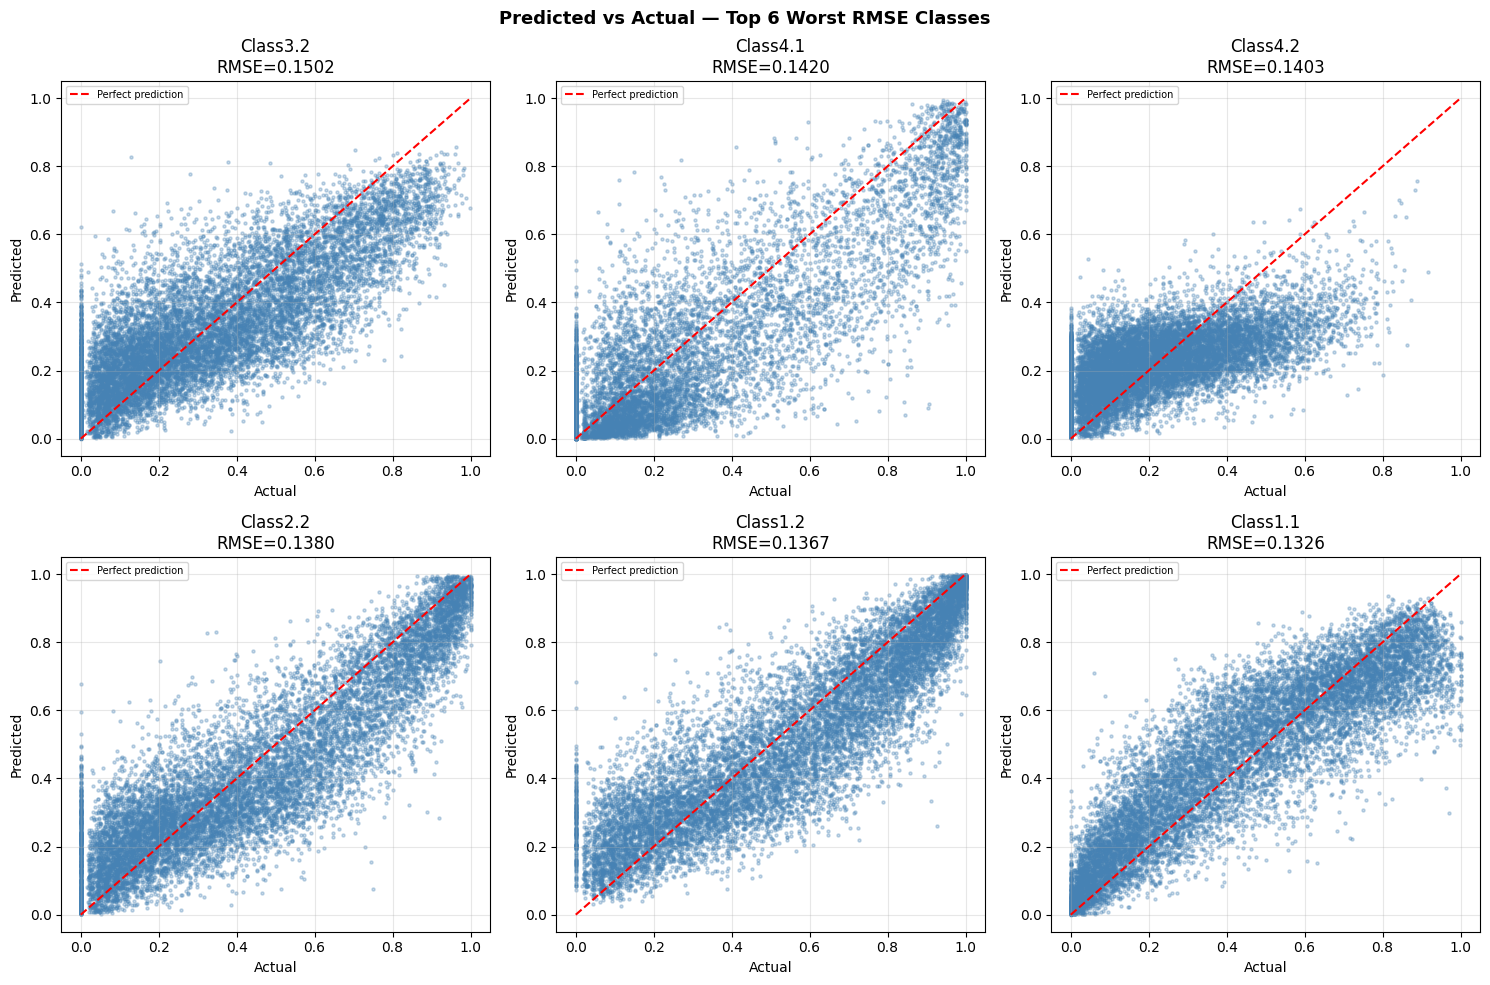

In [15]:
n_scatter = 6
selected_classes = np.argsort(per_class_rmse)[::-1][:n_scatter]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, cls_idx in enumerate(selected_classes):
    ax = axes[i]
    ax.scatter(y_true[:, cls_idx], y_pred[:, cls_idx], alpha=0.3, s=5, color='steelblue')
    ax.plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{label_cols[cls_idx]}\nRMSE={per_class_rmse[cls_idx]:.4f}')
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle('Predicted vs Actual — Top 6 Worst RMSE Classes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

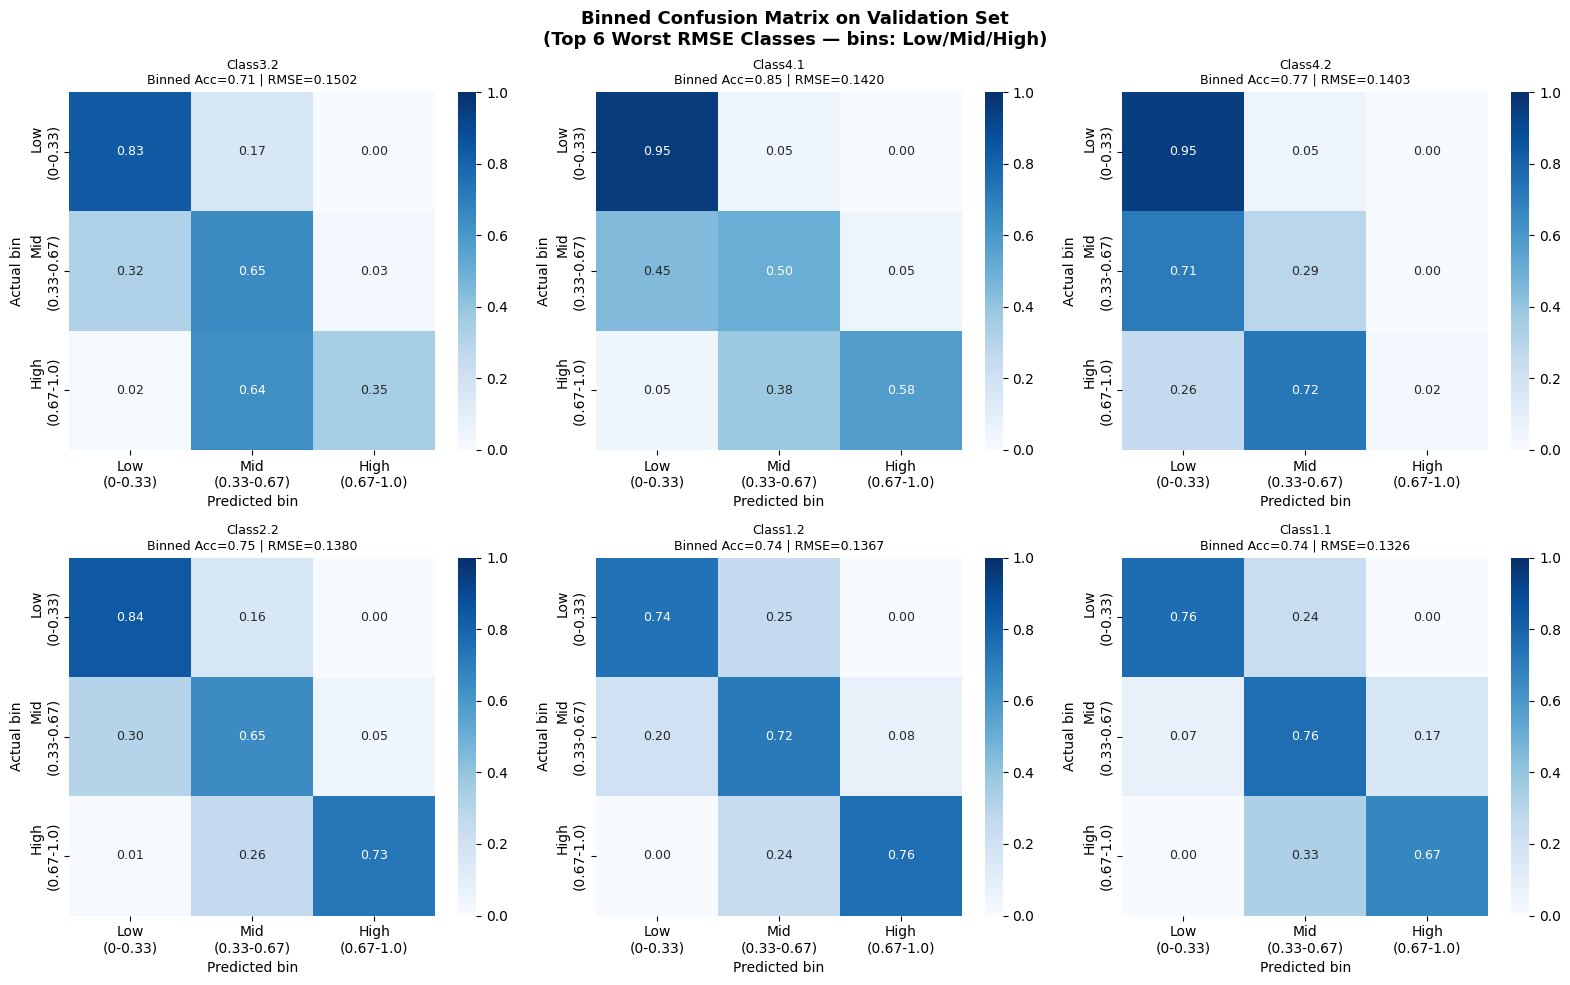

In [16]:
BINS = [0.0, 0.33, 0.67, 1.01]
BIN_LABELS = ['Low\n(0-0.33)', 'Mid\n(0.33-0.67)', 'High\n(0.67-1.0)']

def bin_array(arr):
    return np.digitize(arr, BINS[1:-1])

n_classes_cm = 6
worst_classes = np.argsort(per_class_rmse)[::-1][:n_classes_cm]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, cls_idx in enumerate(worst_classes):
    true_binned = bin_array(y_true[:, cls_idx])
    pred_binned = bin_array(y_pred[:, cls_idx])

    cm = np.zeros((3, 3), dtype=int)
    for t, p in zip(true_binned, pred_binned):
        cm[t, p] += 1

    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    cm_norm = np.nan_to_num(cm_norm)

    sns.heatmap(cm_norm, annot=True, fmt='.2f', ax=axes[i],
                xticklabels=BIN_LABELS, yticklabels=BIN_LABELS,
                cmap='Blues', vmin=0, vmax=1,
                annot_kws={'size': 9})

    total_correct = np.diag(cm).sum()
    acc = total_correct / cm.sum()
    axes[i].set_title(f'{label_cols[cls_idx]}\nBinned Acc={acc:.2f} | RMSE={per_class_rmse[cls_idx]:.4f}', fontsize=9)
    axes[i].set_xlabel('Predicted bin')
    axes[i].set_ylabel('Actual bin')

plt.suptitle('Binned Confusion Matrix on Validation Set\n(Top 6 Worst RMSE Classes — bins: Low/Mid/High)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

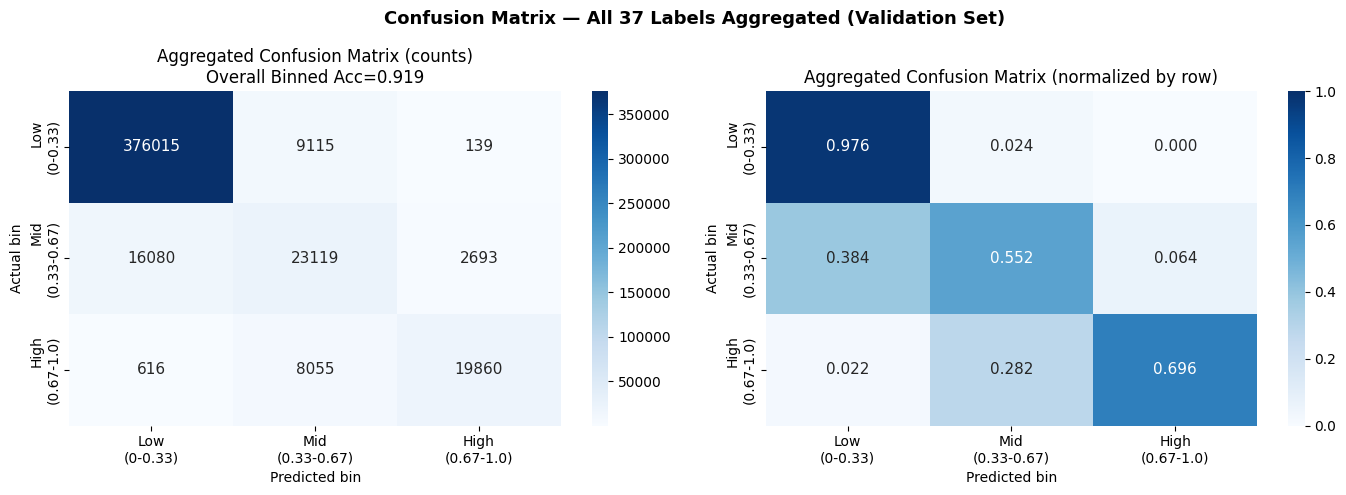

Overall binned accuracy across all 37 labels: 0.9195


In [17]:
all_true_binned = bin_array(y_true.flatten())
all_pred_binned = bin_array(y_pred.flatten())

cm_all = np.zeros((3, 3), dtype=int)
for t, p in zip(all_true_binned, all_pred_binned):
    cm_all[t, p] += 1

cm_all_norm = cm_all.astype(float) / cm_all.sum(axis=1, keepdims=True)
total_acc = np.diag(cm_all).sum() / cm_all.sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_all, annot=True, fmt='d', ax=axes[0],
            xticklabels=BIN_LABELS, yticklabels=BIN_LABELS,
            cmap='Blues', annot_kws={'size': 11})
axes[0].set_title(f'Aggregated Confusion Matrix (counts)\nOverall Binned Acc={total_acc:.3f}')
axes[0].set_xlabel('Predicted bin')
axes[0].set_ylabel('Actual bin')

sns.heatmap(cm_all_norm, annot=True, fmt='.3f', ax=axes[1],
            xticklabels=BIN_LABELS, yticklabels=BIN_LABELS,
            cmap='Blues', vmin=0, vmax=1, annot_kws={'size': 11})
axes[1].set_title('Aggregated Confusion Matrix (normalized by row)')
axes[1].set_xlabel('Predicted bin')
axes[1].set_ylabel('Actual bin')

plt.suptitle('Confusion Matrix — All 37 Labels Aggregated (Validation Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Overall binned accuracy across all 37 labels: {total_acc:.4f}")

In [18]:
out_path = model.name + '.keras'
model.save(out_path)
print("Model saved: {}".format(out_path))

Model saved: galaxyClassifier.keras


In [19]:
test_images_path = tf.io.gfile.glob('../temp/images_test_rev1/*')
test_dataset = dataset_preprocessing(test_images_path, training=False)
print('Test batches: %d' % tf.data.experimental.cardinality(test_dataset))

print('------- Predicting -------')
result = model.predict(test_dataset, verbose=1)
print("Result shape: {}".format(result.shape))

Test batches: 1250
------- Predicting -------
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 177s 141ms/step
Result shape: (79975, 37)


In [20]:
predictions = np.vstack(np.array(result))
galaxyIDs = np.array([os.path.basename(v).replace('.jpg', '') for v in test_images_path]).reshape(len(test_images_path), 1)
submission = pd.DataFrame(np.hstack((galaxyIDs, predictions)), columns=labels_pd.columns)
submission = submission.sort_values(by=['GalaxyID'])
submission.to_csv('submission.csv', index=False)
print("Submission shape: {}".format(submission.shape))
print("Saved: submission.csv")
submission.head()

Submission shape: (79975, 38)
Saved: submission.csv


,GalaxyID,Class1.1,Class1.2,Class1.3,Class2.1,Class2.2,Class3.1,Class3.2,Class4.1,Class4.2,...,Class9.3,Class10.1,Class10.2,Class10.3,Class11.1,Class11.2,Class11.3,Class11.4,Class11.5,Class11.6
57439,100018,0.53346384,0.45334795,0.017329108,0.032430377,0.41509497,0.058748823,0.3625682,0.12071193,0.30367765,...,0.0027225227,0.070928305,0.033918407,0.009776187,0.004724374,0.024849758,0.0008080921,0.00020234716,0.0013245152,0.079483084
1398,100037,0.46866283,0.51224154,0.012981428,0.3540813,0.16346677,0.019555068,0.13659537,0.04748378,0.11153403,...,0.2861266,0.020549199,0.009082994,0.0066472874,0.0004528812,0.009020019,1.8656816e-05,3.1894872e-06,1.0976648e-06,0.030142259
72203,100042,0.6805489,0.28740957,0.008803291,0.17492649,0.10092407,0.006466164,0.07808365,0.012334643,0.083388455,...,0.09008414,0.0070973993,0.0015252415,0.0005643594,2.4632793e-05,0.00096981943,1.619068e-07,1.9535138e-08,2.3372883e-07,0.011610449
18648,100052,0.5954956,0.37818834,0.027288474,0.0017466549,0.36634758,0.022011556,0.34738785,0.06955717,0.2976946,...,1.16100655e-05,0.041520663,0.018590674,0.0043635233,0.0033273264,0.008428983,0.00055474846,0.00013175987,0.0012440551,0.051829223
40084,100056,0.3233527,0.666116,0.004570861,0.644576,0.031635575,0.0028041934,0.028734919,0.006860606,0.025029838,...,0.47310618,0.0029694468,0.0009066145,0.0006594939,1.5728576e-05,0.001098502,7.692668e-08,3.620559e-08,2.6759261e-10,0.004508044
